# Dependencias y constantes

In [ ]:
# Import de librerías importantes
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd

# Librerías utilizadas en algunos análisis
from scipy.stats import linregress                  # Para el análisis de regresión lineal
from sklearn.linear_model import LinearRegression   # Para la regresión lineal múltiple
from sklearn import tree                            # Para la creación de árboles de decisión
from sklearn.ensemble import RandomForestRegressor  # Para la creación de bosques aleatorios (random forest)


# Para poder cargar los módulos escritos en la raíz del proyecto
from pathlib import Path
import sys

RAIZ_PROYECTO = Path().resolve().parent
sys.path.insert(0, str(RAIZ_PROYECTO))

from src.estadistica import *
from src.representacion import *

R_DATAFRAME = "../datos/out/df_long.csv"            # Ruta del dataframe en csv
DIR_SALIDA = "../salida"

SEMILLA = 1905                                      # Semilla para la generación de números aleatorios

In [3]:
# Funciones muy utilizadas en el cuaderno
def dataframe():
    """Función para cargar el dataframe desde el csv y convertir la columna Datetime a formato datetime."""
    df = pd.read_csv(R_DATAFRAME, parse_dates=['Datetime'])
    return df

# Cuaderno de estudio de configuración de placas

Este cuaderno Jupyter busca comprobar el peso de distintas configuraciones en la disposición de las placas respecto a la potencia que son capaces de generar.

## Comprobación del impacto de la configuración

Uno de los objetivos de este estudio es comprobar si la configuración de las placas tienen un impacto significativo en la potencia generada. Para comprobarlo, se compararán distintas configuraciones y se analizarán los resultados obtenidos.

### Impacto de la posición de las placas

En la planta experimental se encuentran tres posiciones en las que las placas se pueden encontrar instaladas:
1. La izquierda (al este) del grupo.
2. La derecha (al oeste) del grupo.
3. En el centro del grupo.

Esta sección buscará la importancia de la posición de las placas comparando los resultados obtenidos en cada una de las posiciones.

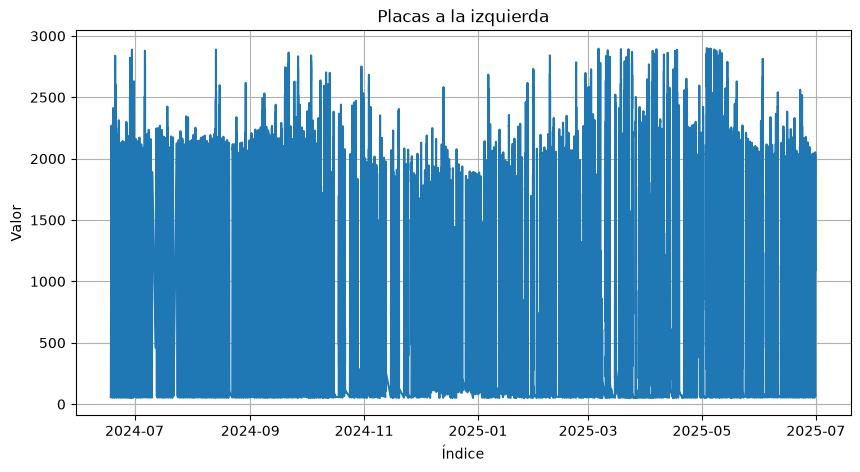

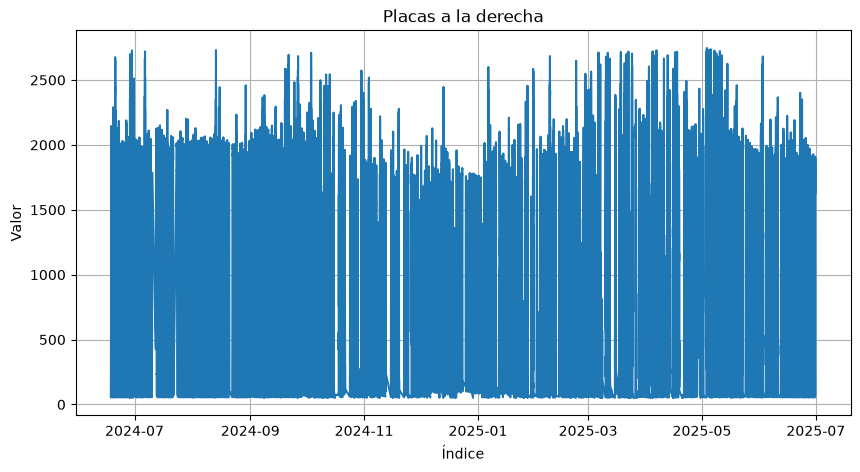

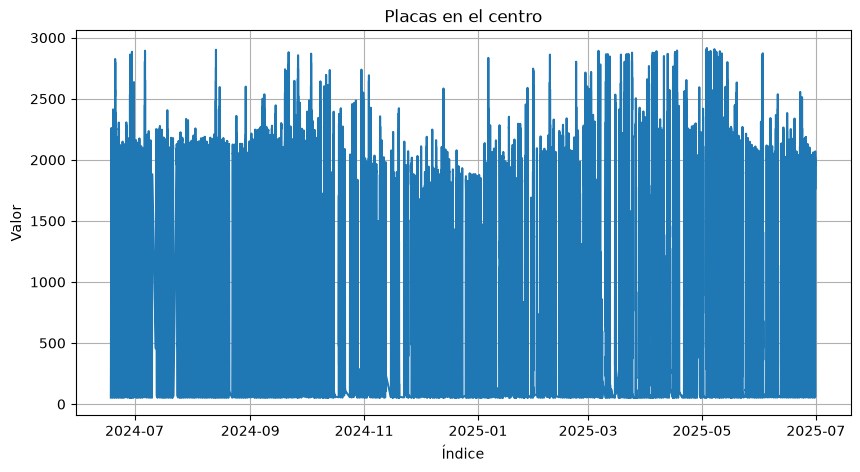

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
Placas a la izquierda contra placas a la derecha & 77.651012 & 65.348629 & 5.714651 \\
Placas a la izquierda contra placas en el centro & 13.616001 & 6.305504 & 0.947484 \\
Placas a la derecha contra placas en el centro & 77.407879 & 64.715538 & 6.074461 \\
\bottomrule
\end{tabular}



In [22]:
# Hago tres columnas nuevas para poder filtrar por posición de las placas
df_izq = df.where(df["Disp_Izq"] == 1)
df_der = df.where(df["Disp_Der"] == 1)
df_cent = df.where(df["Disp_Cent"] == 1)

# Grafico la media de potencia leída por las placas en cada instante de tiempo, para cada posición de las placas
mostrar_serie(
    serie=df_izq.groupby("Datetime")["Pdc"].mean(),
    titulo="Placas a la izquierda"
)
mostrar_serie(
    serie=df_der.groupby("Datetime")["Pdc"].mean(),
    titulo="Placas a la derecha"
)
mostrar_serie(
    serie=df_cent.groupby("Datetime")["Pdc"].mean(),
    titulo="Placas en el centro"
)

# Calculamos las diferencias dos a dos
izq_vs_der = fila_diferencia_series(
    "Placas a la izquierda contra placas a la derecha",
    serie1=df_izq.groupby("Datetime")["Pdc"].mean(),
    serie2=df_der.groupby("Datetime")["Pdc"].mean()
)

izq_vs_centro = fila_diferencia_series(
    "Placas a la izquierda contra placas en el centro",
    serie1=df_izq.groupby("Datetime")["Pdc"].mean(),
    serie2=df_cent.groupby("Datetime")["Pdc"].mean()
)

der_vs_centro = fila_diferencia_series(
    "Placas a la derecha contra placas en el centro",
    serie1=df_der.groupby("Datetime")["Pdc"].mean(),
    serie2=df_cent.groupby("Datetime")["Pdc"].mean()
)

print(tabla_diferencias(filas=[izq_vs_der, izq_vs_centro, der_vs_centro]))